In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
#LOAD & CLEAN ---
df = pd.read_csv('academIQ_clean_dataset.csv').drop_duplicates()

#Creating new attributes to boost accuracy
# We create these columns because they help the model understand "density" of activity.
df['avg_daily_time'] = df['total_time_spent'] / (df['active_days'] + 1)
df['clicks_per_day'] = df['all_clicks'] / (df['active_days'] + 1)


# Select behavioral features (exclude IDs and Target)
feature_cols = ['all_clicks', 'active_days', 'access_frequency', 'material_clicks',
                'avg_quiz_score', 'quiz_attempts', 'avg_assignment_score',
                'assignment_submissions', 'total_time_spent', 'avg_daily_time', 'clicks_per_day']
X_raw = df[feature_cols]

In [ ]:
#SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

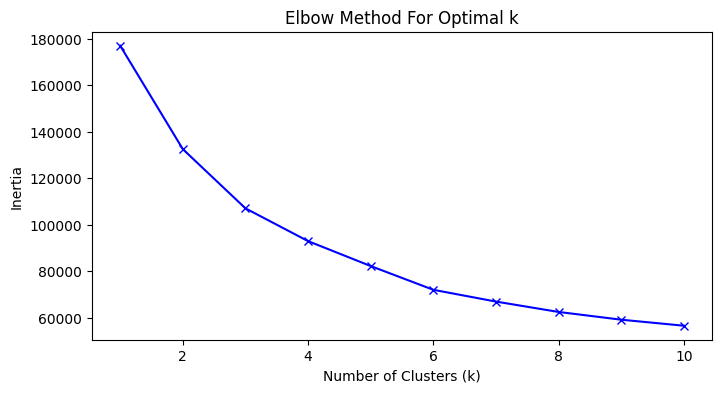

In [ ]:
#ELBOW METHOD ---
inertia = []
K_range = range(1, 11)
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Visualize the Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:
#NUMERIC CLUSTERING (Filling risk_cluster) ---
# We use K=4 based on the elbow point
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['risk_cluster'] = kmeans.fit_predict(X_scaled)

# Add risk_cluster to our feature set for the classifier
feature_cols_final = feature_cols + ['risk_cluster']
X = df[feature_cols_final]

In [ ]:
#CATEGORIZE GRADES (Target) ---
def map_grade(score):
    if score > 85:
        return "A"
    elif score >= 70:
        return "B"
    elif score >= 60:
        return "C"
    elif score >= 50:
        return "D"
    else:
        return "F"

df['grade_category'] = df['final_grade'].apply(map_grade)
y = df['grade_category']

In [ ]:
#TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# --- 7. CLASSIFIER (Prediction) ---
#model = RandomForestClassifier(n_estimators=100, random_state=42)
#model.fit(X_train, y_train)


# 7. ENHANCED CLASSIFIER (Gradient Boosting)
# Gradient Boosting is generally more accurate than Random Forest for this type of data
model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=5, n_estimators=200, random_state=42)

In [ ]:
#EVALUATION ---
predictions = model.predict(X_test)
print(f"Prediction Accuracy: {accuracy_score(y_test, predictions):.2%}")
print(classification_report(y_test, predictions))

Prediction Accuracy: 73.40%
              precision    recall  f1-score   support

           B       0.56      0.39      0.46       336
           C       0.67      0.78      0.72      1358
           F       0.83      0.77      0.80      1524

    accuracy                           0.73      3218
   macro avg       0.69      0.65      0.66      3218
weighted avg       0.74      0.73      0.73      3218

